In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD, Adam
import matplotlib.pyplot as plt
import numpy as np
from imgaug import augmenters as iaa
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
from torchvision import datasets

# pasta com datasets
data_folder = 'data'

# baixando os dados de treino do dataset
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

# baixando os dados de teste do dataset
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

/home/liperasz/anaconda3/envs/card-21/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /home/liperasz/anaconda3/envs/card-21/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


100.0%


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100.0%


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100.0%


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100.0%

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



In [3]:
# geranndo novas imagens
aug = iaa.Sequential([
    iaa.Affine(translate_px={'x':(-10, 10)},
               mode='constant'),
])

In [4]:
# classe para definir o dataset
class FMNISTDataset(Dataset):
    def __init__(self, x, y, aug=None):
        self.x, self.y = x, y
        self.aug = aug
    
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x, y
    
    def __len__(self):
        return len(self.x)
    
    def collate_fn(self, batch):
        # modifica um batch de imagens
        ims, classes = list(zip(*batch))
        if self.aug:
            ims_np = np.array([tensor.numpy() for tensor in ims])
            ims = self.aug.augment_images(images=ims_np)

        ims = torch.tensor(ims)[:,None,:,:].to(device)/255
        classes = torch.tensor(classes).to(device)
        return ims, classes

In [9]:
# função para criar a rede neural
def get_model():
    model = nn.Sequential(
        nn.Conv2d(1, 64, kernel_size=3),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Conv2d(64, 128, kernel_size=3),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(3200, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)
    return model, loss_fn, optimizer

In [10]:
# função para o treinamento dos batches
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()

In [11]:
# função para requisitar os dados preparados
def get_data():
    # dados de treinamento
    train = FMNISTDataset(tr_images, tr_targets, aug=aug)
    trn_dl = DataLoader(train, batch_size=64, collate_fn=train.collate_fn, shuffle=True)
    # dados de teste
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), collate_fn=val.collate_fn, shuffle=True)

    return trn_dl, val_dl

In [12]:
# atributi os dados
trn_dl, val_dl = get_data()
# atribui o modelo da rede neural
model, loss_fn, optimizer = get_model()
# definidas 5 épocas
for epoch in range(5):
    print(epoch)
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        # treinamento
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)

0
1
2
3
4


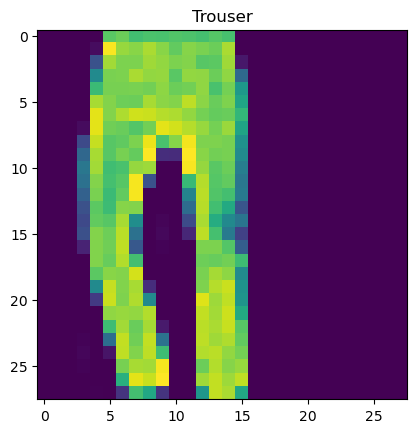

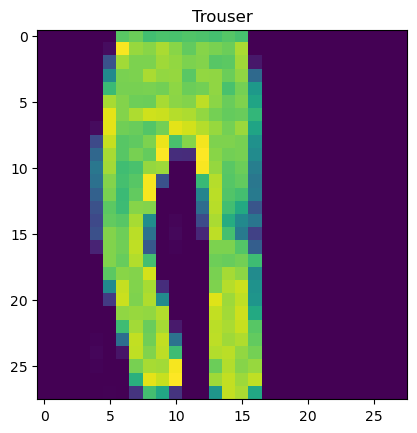

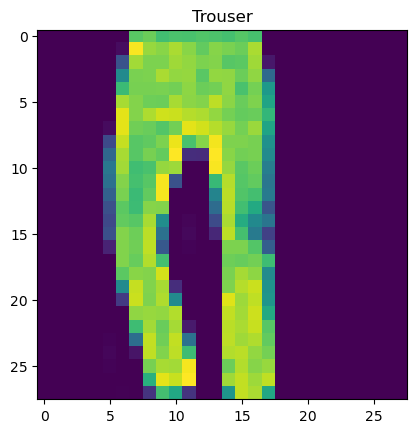

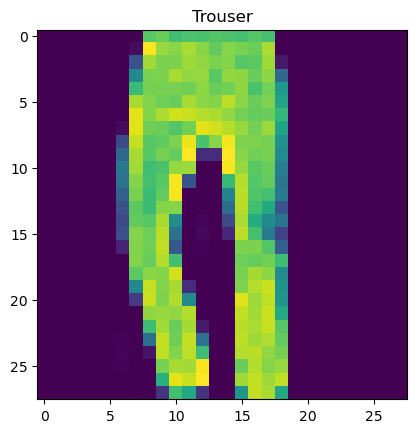

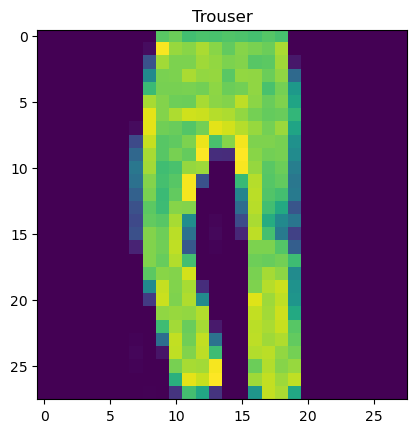

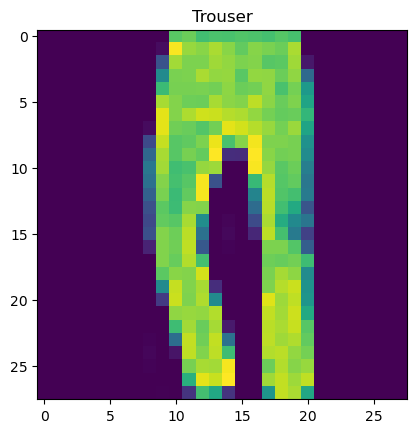

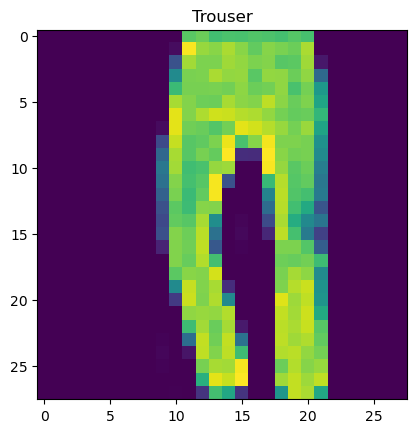

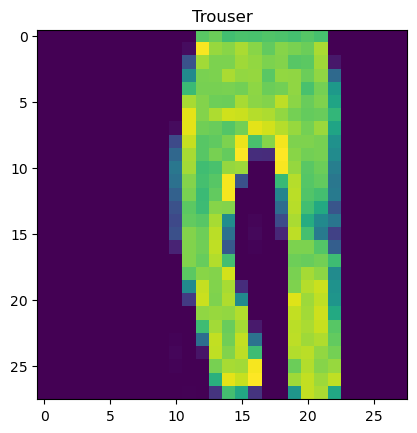

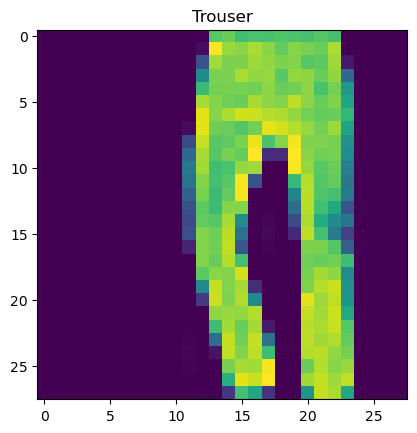

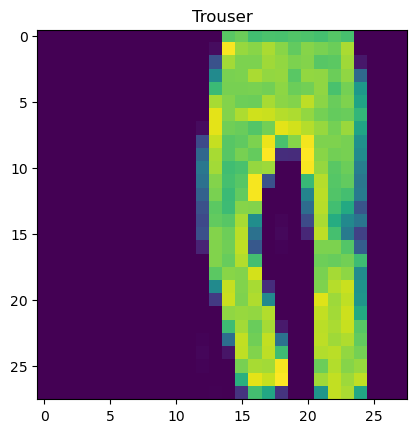

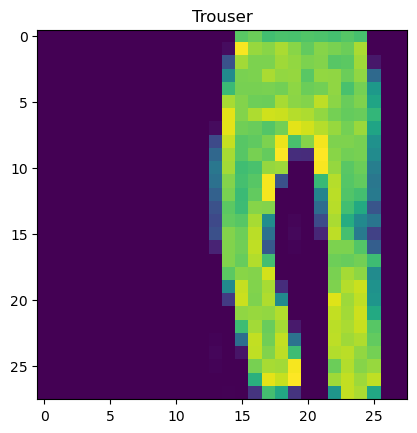

In [13]:
# lista para predições
preds = []
ix = 24300

# passa a imagem para o lado de pouco em pouco
for px in range(-5, 6):
    img = tr_images[ix]/255.
    img = img.view(28, 28)
    img2 = np.roll(img, px, axis=1)
    img3 = torch.Tensor(img2).view(-1, 1, 28, 28).to(device)
    np_output = model(img3).cpu().detach().numpy()
    pred = np.exp(np_output)/np.sum(np.exp(np_output))
    preds.append(pred)

    # plotar a imagem
    plt.imshow(img2)
    plt.title(fmnist.classes[pred[0].argmax()])
    plt.show()